# OBJECTIVE

In [1]:
# Importing libraries and loading the ludo dataset
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

# Resolve dataset path robustly (works from repo root or jupyter_notebooks/)
candidate_paths = [
    Path("data file/Raw_Data/ludo_dataset.csv"),
    Path("../data file/Raw_Data/ludo_dataset.csv"),
]

dataset_path = next((p for p in candidate_paths if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError("Could not find ludo_dataset.csv in expected locations.")

df = pd.read_csv(dataset_path)
df.head()

,Game_ID,Turn,Player,Dice_Roll,Position,Is_Winner
0,0,1,Red,1,1,0
1,0,2,Green,5,5,0
2,0,3,Yellow,4,4,0
3,0,4,Blue,6,6,1
4,0,5,Red,1,2,0


In [2]:
df.describe(include='all')

,Game_ID,Turn,Player,Dice_Roll,Position,Is_Winner
count,10021.000000,10021.000000,10021,10021.000000,10021.000000,10021.000000
unique,NaN,NaN,4,NaN,NaN,NaN
top,NaN,NaN,Red,NaN,NaN,NaN
freq,NaN,NaN,2575,NaN,NaN,NaN
mean,86.078435,30.034527,NaN,3.518112,26.986029,0.256960
std,49.718493,17.737766,NaN,1.717701,14.955376,0.436979
min,0.000000,1.000000,NaN,1.000000,1.000000,0.000000
25%,44.000000,15.000000,NaN,2.000000,14.000000,0.000000
50%,86.000000,29.000000,NaN,4.000000,27.000000,0.000000
75%,129.000000,44.000000,NaN,5.000000,40.000000,1.000000


In [3]:
df.isnull().sum()

Game_ID      0
Turn         0
Player       0
Dice_Roll    0
Position     0
Is_Winner    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

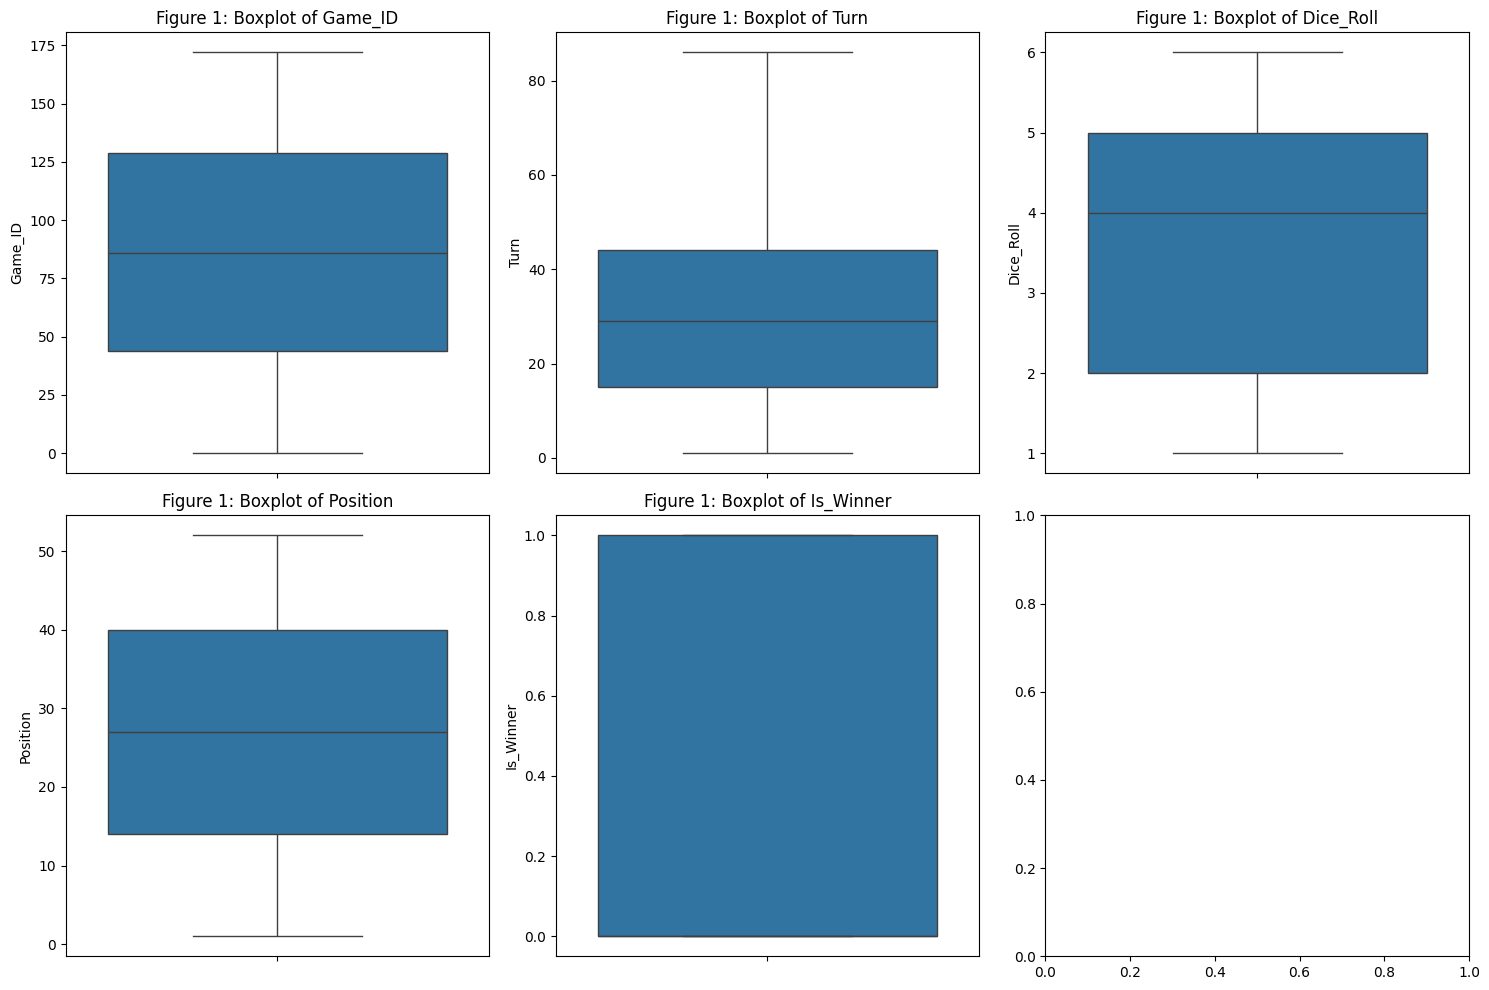

In [5]:
# Checking for outliers in the numeric variables using boxplots
df_num=df.select_dtypes(include=[np.number])
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(df_num.columns):
    sns.boxplot(y=df_num[col], ax=axes[i])
    axes[i].set_title(f'Figure 1: Boxplot of {col}')
plt.tight_layout()
plt.show()


In [6]:
# Save the cleaned dataset to a new CSV file
cleaned_dataset_path = dataset_path.parent / "ludo_dataset_cleaned.csv"
df.to_csv(cleaned_dataset_path, index=False)


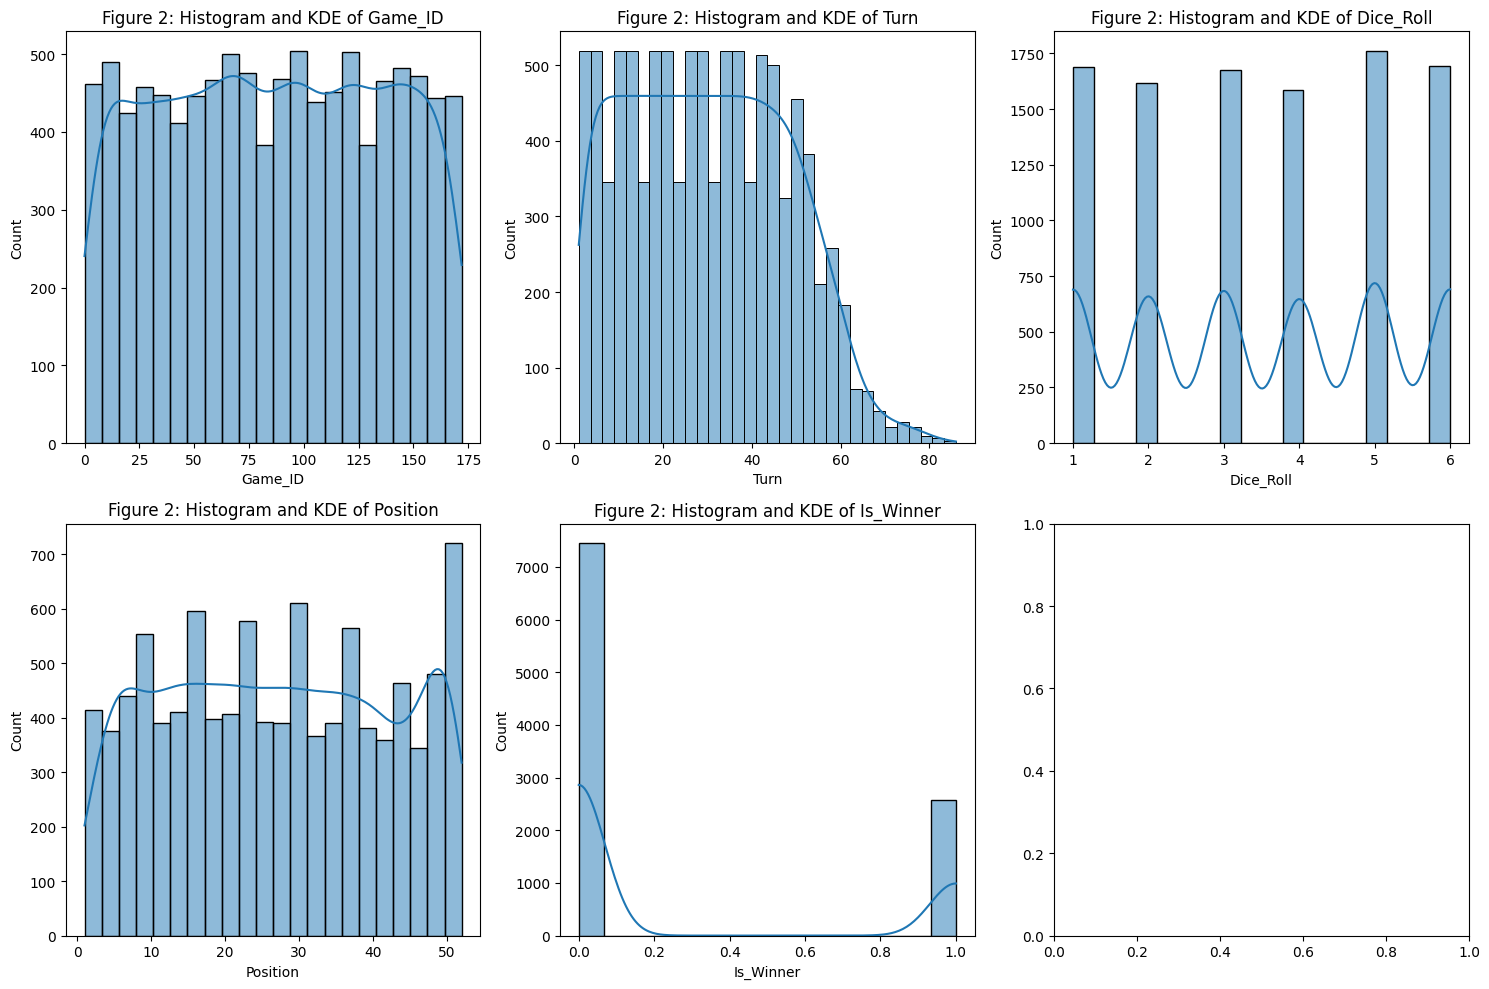

In [7]:
# Visualize the numeric variables using histograms and KDE plots
df_num=df.select_dtypes(include=[np.number])
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(df_num.columns):
    sns.histplot(df_num[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Figure 2: Histogram and KDE of {col}')
plt.tight_layout()
plt.show()

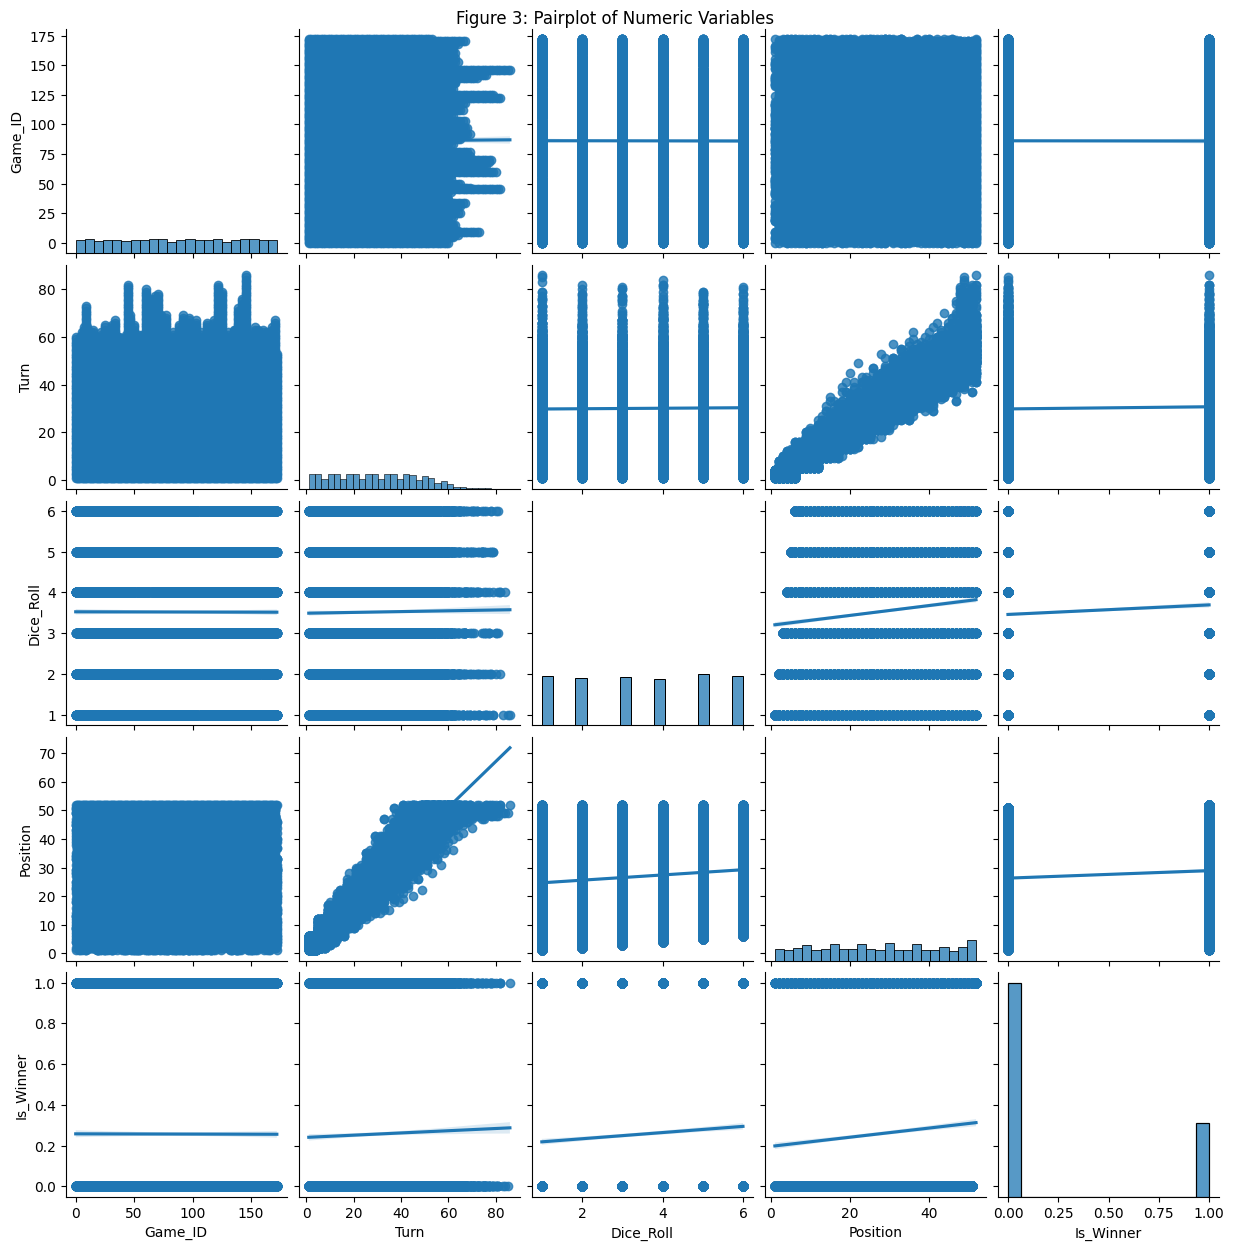

In [8]:
# Visualization of the relationships between numeric variables using pairplot with a regression line
sns.pairplot(df_num, kind='reg')
plt.suptitle('Figure 3: Pairplot of Numeric Variables', y=1)
plt.show()

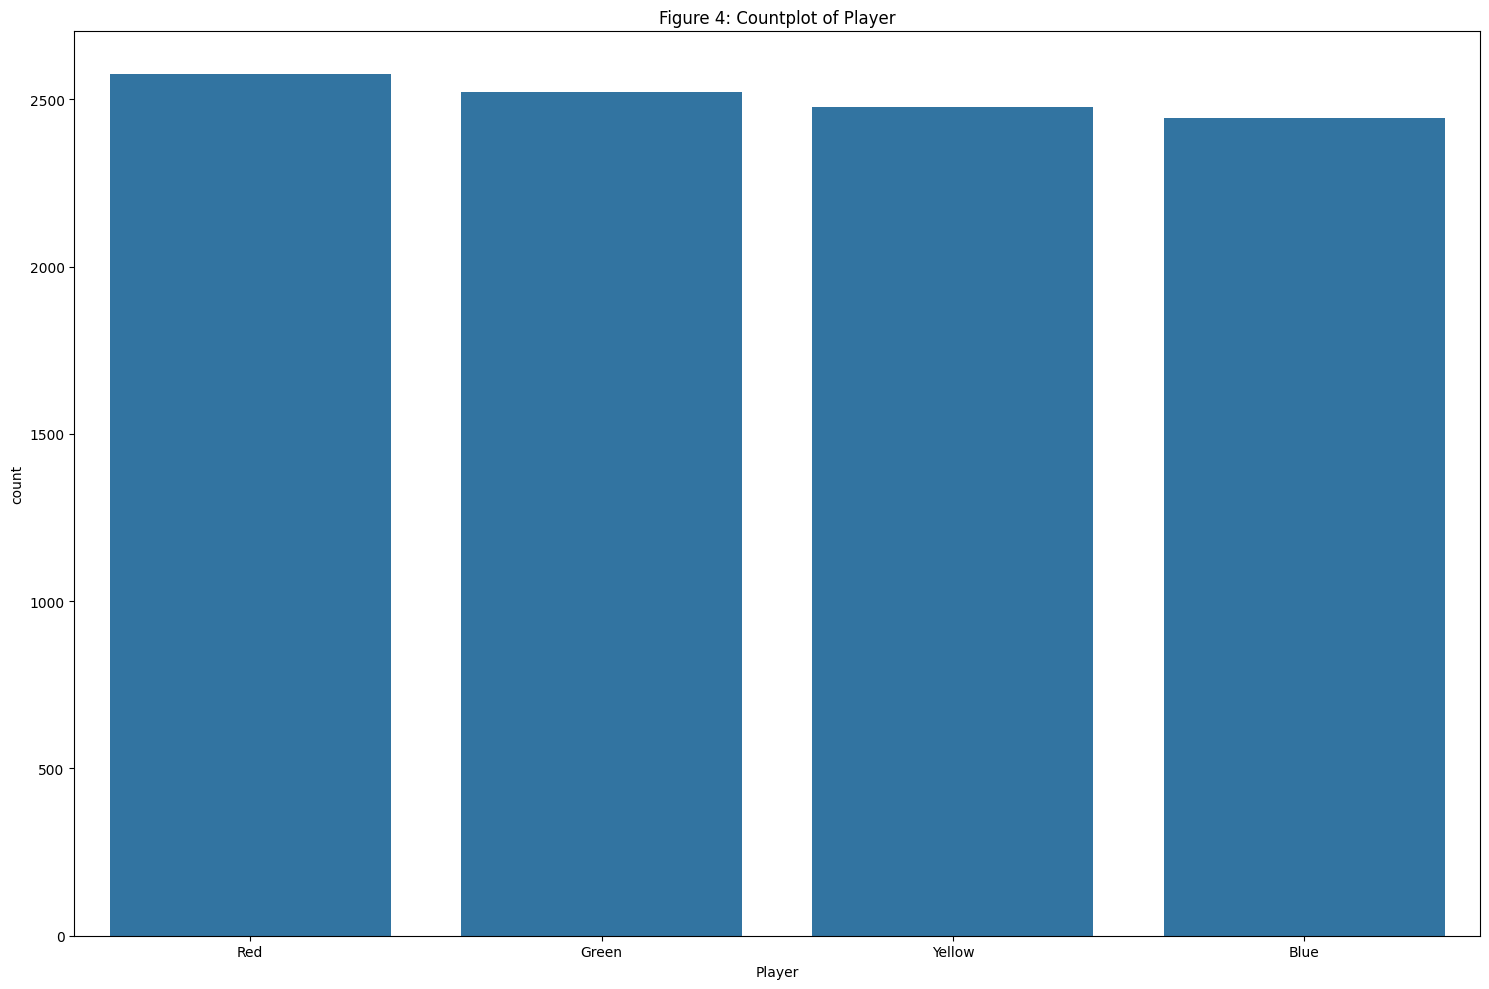

In [9]:
# Distribution of categorical variables using countplots removing unnecessary axes

df_cat=df.select_dtypes(include=['object'])
figure= plt.subplots(nrows=1, ncols=1, figsize=(15, 10))
for i, col in enumerate(df_cat.columns):
    sns.countplot(x=df_cat[col], ax=plt.gca())
    plt.title(f'Figure 4: Countplot of {col}')
plt.tight_layout()
plt.show()

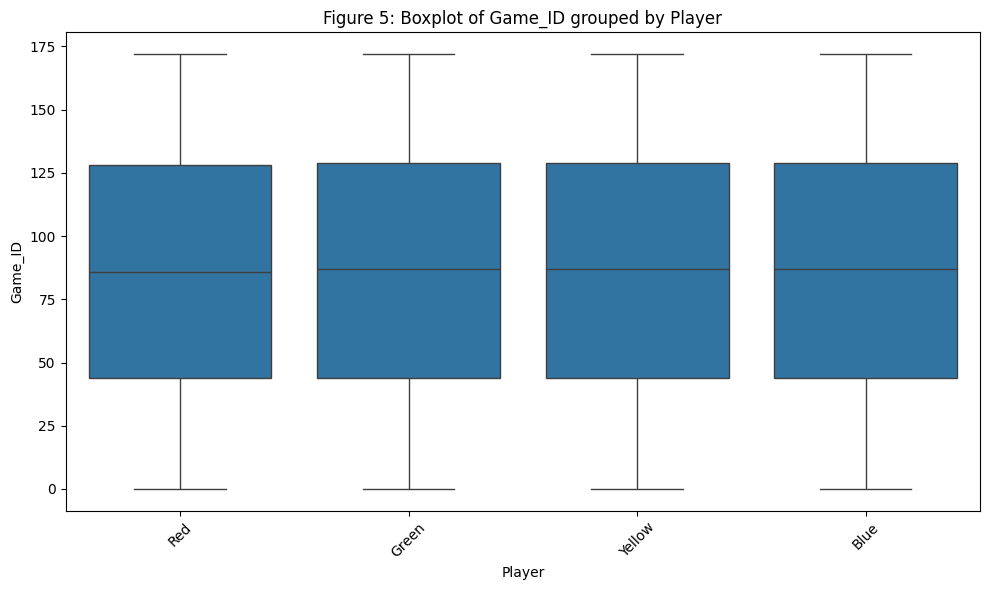

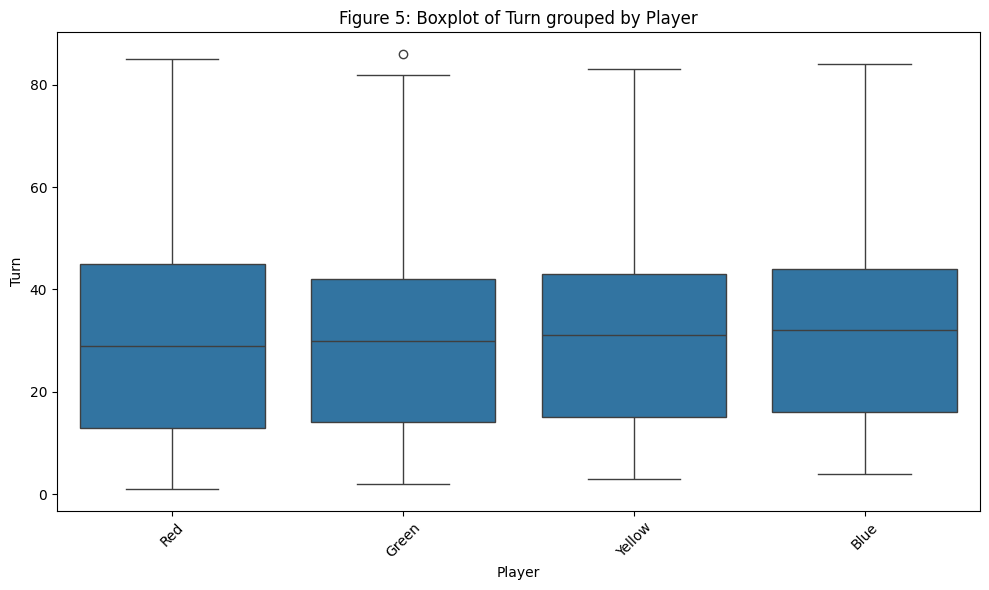

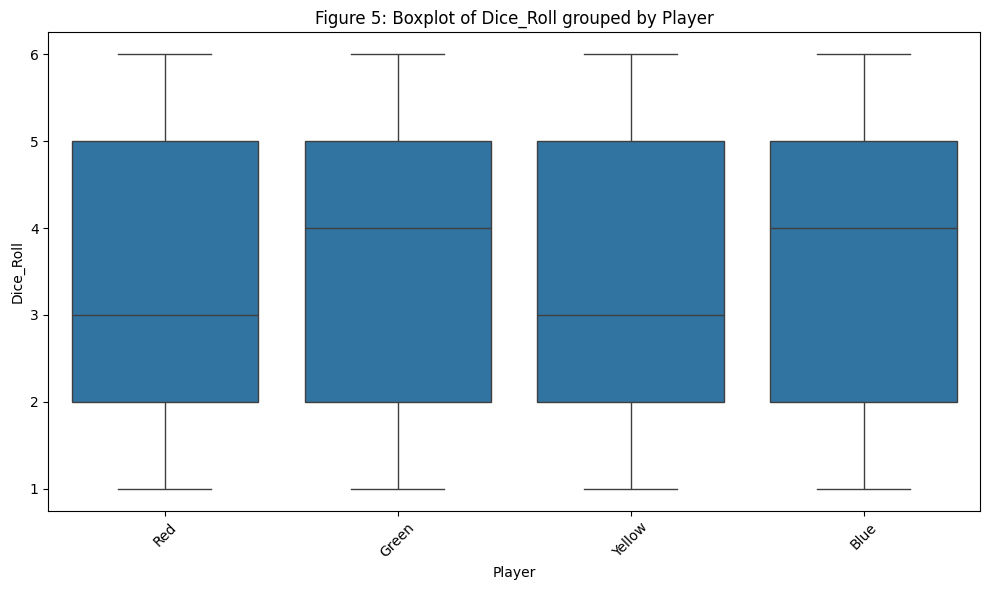

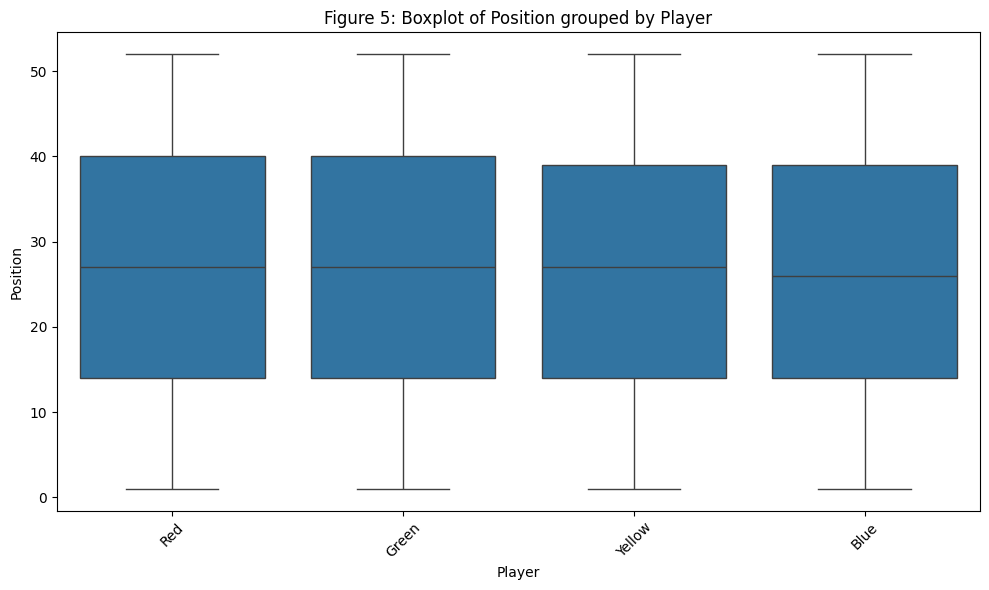

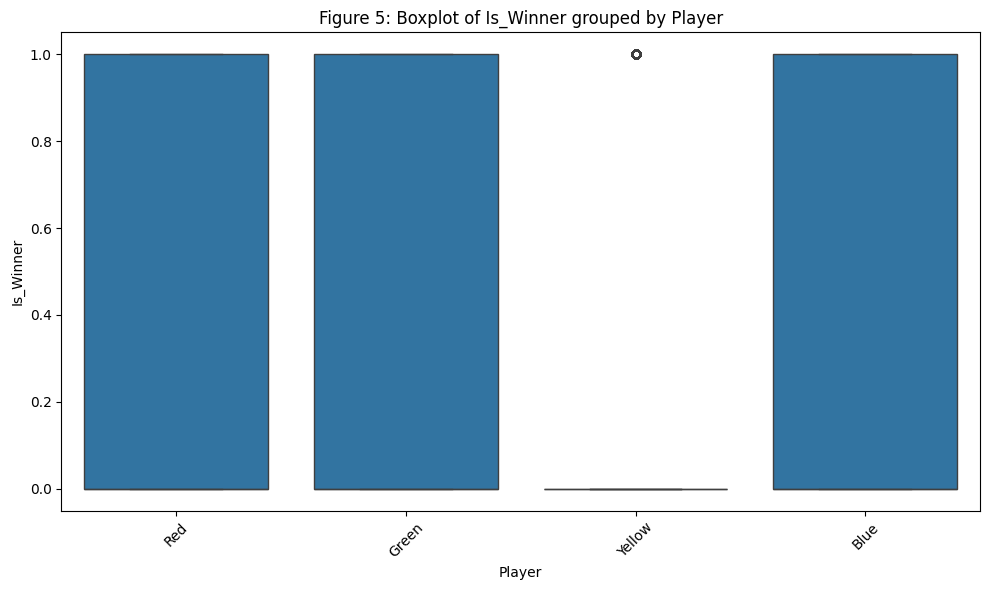

In [10]:
 # Distribution of the numeric variables when grouped by the categorical variables using boxplots
for cat_col in df_cat.columns:
    for num_col in df_num.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=df[cat_col], y=df[num_col])
        plt.title(f'Figure 5: Boxplot of {num_col} grouped by {cat_col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Statistical Tests

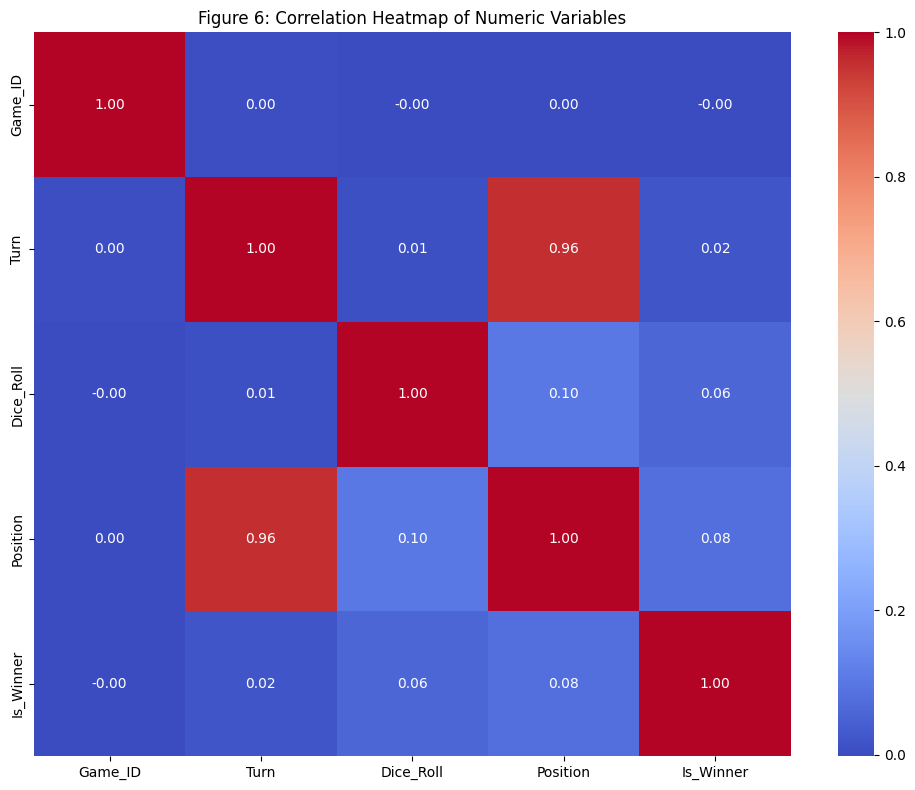

In [11]:
# Correlation heatmap of numeric variables
plt.figure(figsize=(10, 8))
correlation_matrix = df_num.corr(method='spearman')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Figure 6: Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

In [12]:
# Tests for normality of numeric variables with automatic method switch from shapiro to normaltest(n > 5000), alpha=0.05
normality_rows = []
alpha = 0.05

for col in df_num.columns:
    series = df_num[col].dropna()
    method = 'normaltest' if len(series) > 5000 else 'shapiro'
    result = pg.normality(series, method=method, alpha=alpha)

    p_value = result['pval'].iloc[0]
    is_normal = bool(result['normal'].iloc[0])
    normality_rows.append({
        'variable': col,
        'n': len(series),
        'test_used': method,
        'statistic': result.iloc[0, 0],
        'p_value': p_value,
        'normal': is_normal,
        'indication': 'Normally distributed' if is_normal else 'Not normally distributed',
    })

normality_df = pd.DataFrame(normality_rows)
normality_df

,variable,n,test_used,statistic,p_value,normal,indication
0,Game_ID,10021,normaltest,7870.332958,0.000000e+00,False,Not normally distributed
1,Turn,10021,normaltest,1082.614733,8.188375e-236,False,Not normally distributed
2,Dice_Roll,10021,normaltest,26013.279113,0.000000e+00,False,Not normally distributed
3,Position,10021,normaltest,8424.187961,0.000000e+00,False,Not normally distributed
4,Is_Winner,10021,normaltest,2099.861856,0.000000e+00,False,Not normally distributed


In [ ]:
# Tests for normality of numeric variables within each category level, alpha=0.05
grouped_normality_rows = []
alpha = 0.05

for cat_col in df_cat.columns:
    for num_col in df_num.columns:
        subset = df[[cat_col, num_col]].dropna()
        for group_name, group_df in subset.groupby(cat_col):
            series = group_df[num_col]
            n = len(series)

            if n < 3:
                grouped_normality_rows.append({
                    'categorical_variable': cat_col,
                    'category': group_name,
                    'numeric_variable': num_col,
                    'n': n,
                    'test_used': None,
                    'statistic': np.nan,
                    'p_value': np.nan,
                    'normal': False,
                    'indication': 'Insufficient sample size (n < 3)'
                })
                continue

            method = 'normaltest' if n > 5000 else 'shapiro'
            result = pg.normality(series, method=method, alpha=alpha)

            p_value = result['pval'].iloc[0]
            is_normal = bool(result['normal'].iloc[0])

            grouped_normality_rows.append({
                'categorical_variable': cat_col,
                'category': group_name,
                'numeric_variable': num_col,
                'n': n,
                'test_used': method,
                'statistic': result.iloc[0, 0],
                'p_value': p_value,
                'normal': is_normal,
                'indication': 'Normally distributed' if is_normal else 'Not normally distributed'
            })

grouped_normality_df = pd.DataFrame(grouped_normality_rows)
grouped_normality_df

AssertionError: 